# EP06 — Generative AI: GANs & Diffusion Models
**Exam Relevance:** 2025 Q7.1 (9 marks) | 2024 Q6 (MCQ + questions)

Topics:
1. GAN architecture: Generator vs Discriminator objectives
2. Diffusion models: core idea of noising and denoising
3. Autoencoders and VAEs (2024 MCQ)
4. Why diffusion uses small steps, not one big jump

---

## 1. GAN — Training Objectives

**2025 Q7.1a asked:** *Briefly describe the training objectives of the generator and discriminator.*

### The Adversarial Game:

**Generator (G):**
- Takes random noise z as input
- Generates fake images G(z)
- Objective: **fool the discriminator** — make G(z) look so realistic that D predicts it as real (D(G(z)) → 1)
- Wants to MAXIMISE D(G(z)) (or equivalently minimise log(1 - D(G(z))))

**Discriminator (D):**
- Takes an image (real or fake) as input
- Objective: **correctly distinguish real from fake** 
  - D(real image) → 1 (output high probability for real)
  - D(G(z)) → 0 (output low probability for fake)
- Wants to MAXIMISE log(D(x)) + log(1 - D(G(z)))

**Together:** minimax game — G minimises, D maximises the same objective

/Users/arjunkarthik/Applications/MAI/AI/AI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


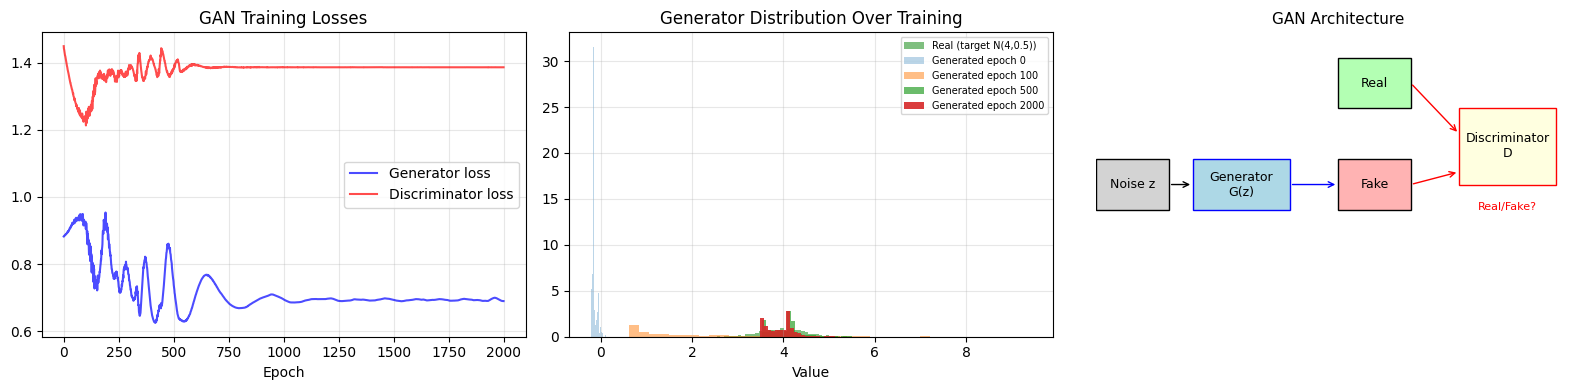

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Mini GAN on 1D data — to show the training dynamics
# Real data: samples from N(4, 0.5)
# Generator: maps noise N(0,1) → tries to match real dist
# ============================================================

torch.manual_seed(42)

class Generator1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16), nn.ReLU(),
            nn.Linear(16, 16), nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, z): return self.net(z)

class Discriminator1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16), nn.ReLU(),
            nn.Linear(16, 16), nn.ReLU(),
            nn.Linear(16, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

G = Generator1D()
D = Discriminator1D()
opt_G = torch.optim.Adam(G.parameters(), lr=0.001)
opt_D = torch.optim.Adam(D.parameters(), lr=0.001)
criterion = nn.BCELoss()

g_losses, d_losses = [], []
snapshots = {}

for epoch in range(2000):
    batch_size = 128
    
    # Real data from N(4, 0.5)
    real = torch.randn(batch_size, 1) * 0.5 + 4.0
    noise = torch.randn(batch_size, 1)
    fake = G(noise).detach()
    
    # --- Train Discriminator ---
    opt_D.zero_grad()
    d_real = criterion(D(real), torch.ones(batch_size, 1))
    d_fake = criterion(D(fake), torch.zeros(batch_size, 1))
    d_loss = d_real + d_fake
    d_loss.backward()
    opt_D.step()
    
    # --- Train Generator ---
    opt_G.zero_grad()
    noise2 = torch.randn(batch_size, 1)
    g_loss = criterion(D(G(noise2)), torch.ones(batch_size, 1))  # G wants D to output 1
    g_loss.backward()
    opt_G.step()
    
    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())
    
    if epoch in [0, 100, 500, 1999]:
        with torch.no_grad():
            snapshots[epoch] = G(torch.randn(1000, 1)).numpy().flatten()

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss curves
axes[0].plot(g_losses, label='Generator loss', alpha=0.7, color='blue')
axes[0].plot(d_losses, label='Discriminator loss', alpha=0.7, color='red')
axes[0].set_title('GAN Training Losses')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution evolution
real_data = np.random.normal(4, 0.5, 1000)
axes[1].hist(real_data, bins=40, alpha=0.5, label='Real (target N(4,0.5))', color='green', density=True)
for epoch, label, alpha in [(0, 'epoch 0', 0.3), (100, 'epoch 100', 0.5), 
                              (500, 'epoch 500', 0.7), (1999, 'epoch 2000', 0.9)]:
    axes[1].hist(snapshots[epoch], bins=40, alpha=alpha, label=f'Generated {label}', density=True)
axes[1].set_title('Generator Distribution Over Training')
axes[1].set_xlabel('Value')
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

# GAN architecture diagram
axes[2].axis('off')
axes[2].set_xlim(0, 10)
axes[2].set_ylim(0, 6)

# Noise
axes[2].add_patch(plt.Rectangle((0, 2.5), 1.5, 1, color='lightgray', ec='black'))
axes[2].text(0.75, 3.0, 'Noise z', ha='center', va='center', fontsize=9)

# Generator
axes[2].add_patch(plt.Rectangle((2, 2.5), 2, 1, color='lightblue', ec='blue'))
axes[2].text(3.0, 3.0, 'Generator\nG(z)', ha='center', va='center', fontsize=9)
axes[2].annotate('', xy=(2, 3.0), xytext=(1.5, 3.0), arrowprops=dict(arrowstyle='->', color='black'))

# Fake image
axes[2].add_patch(plt.Rectangle((5, 2.5), 1.5, 1, color='#FFB3B3', ec='black'))
axes[2].text(5.75, 3.0, 'Fake', ha='center', va='center', fontsize=9)
axes[2].annotate('', xy=(5, 3.0), xytext=(4, 3.0), arrowprops=dict(arrowstyle='->', color='blue'))

# Real image
axes[2].add_patch(plt.Rectangle((5, 4.5), 1.5, 1, color='#B3FFB3', ec='black'))
axes[2].text(5.75, 5.0, 'Real', ha='center', va='center', fontsize=9)

# Discriminator
axes[2].add_patch(plt.Rectangle((7.5, 3.0), 2, 1.5, color='lightyellow', ec='red'))
axes[2].text(8.5, 3.75, 'Discriminator\nD', ha='center', va='center', fontsize=9)
axes[2].annotate('', xy=(7.5, 3.25), xytext=(6.5, 3.0), arrowprops=dict(arrowstyle='->', color='red'))
axes[2].annotate('', xy=(7.5, 4.0), xytext=(6.5, 5.0), arrowprops=dict(arrowstyle='->', color='red'))

axes[2].text(8.5, 2.5, 'Real/Fake?', ha='center', fontsize=8, color='red')
axes[2].set_title('GAN Architecture', fontsize=11)

plt.tight_layout()
plt.show()

## 2. Diffusion Models — Core Idea

**2025 Q7.1b asked:** *What is the core idea behind image generation using diffusion models?*

### Answer:
Diffusion models work in two phases:

1. **Forward process (noising):** Gradually add Gaussian noise to a real image over T timesteps until it becomes pure noise. This is fixed/not learned.

2. **Reverse process (denoising):** A neural network learns to reverse each small noise step — predicting the slightly less noisy image. By iterating T steps, we can start from pure noise and denoise it into a realistic image.

**2024 Q6.1(5) — Why small steps, not one big jump?**  
Answer: **B — Easier to learn and control the process**  
- Each small denoising step is a simpler, more tractable problem
- The network only needs to predict a small amount of noise removal
- One big jump would require predicting a sharp image directly from pure noise — much harder

/var/folders/20/z8cs1fd56xg91ycftn6fzq640000gn/T/ipykernel_60521/330791564.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


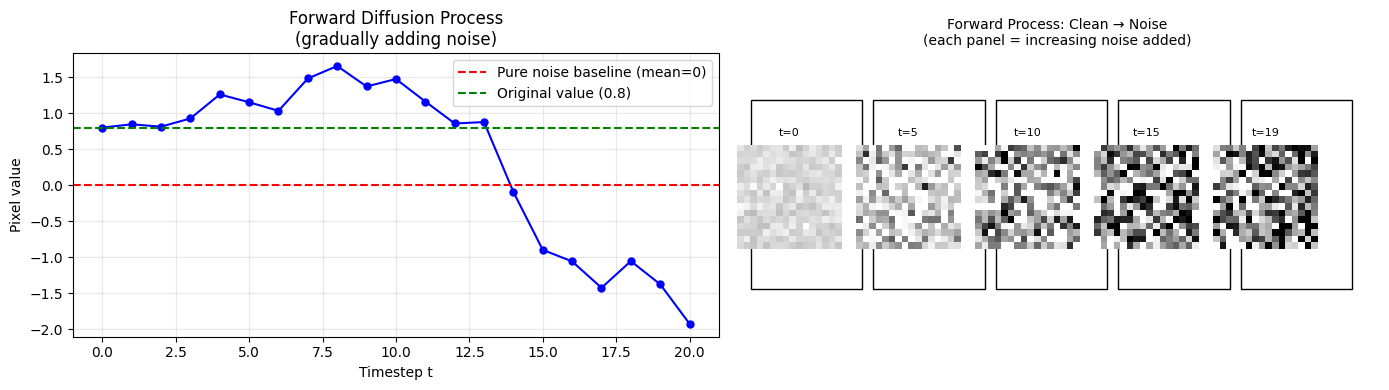

Forward process: x_0 (real image) → x_T (pure noise)  [NOT learned]
Reverse process: x_T (pure noise) → x_0 (real image)  [LEARNED by neural network]
Generation: sample x_T ~ N(0,I), then run reverse process T times


In [3]:
# Visualise the forward diffusion process (adding noise gradually)
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Simulate forward diffusion on a simple 1D signal (representing an image pixel value)
# Real value = 0.8 (a bright pixel)
x_0 = 0.8
T = 20  # timesteps
beta = np.linspace(0.01, 0.3, T)  # noise schedule

x_t_values = [x_0]
x_t = x_0
for t in range(T):
    noise = np.random.normal(0, 1)
    x_t = np.sqrt(1 - beta[t]) * x_t + np.sqrt(beta[t]) * noise
    x_t_values.append(x_t)

# Plot forward process
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(range(T+1), x_t_values, 'b-o', markersize=5)
axes[0].axhline(0, color='red', linestyle='--', label='Pure noise baseline (mean=0)')
axes[0].axhline(x_0, color='green', linestyle='--', label=f'Original value ({x_0})')
axes[0].set_xlabel('Timestep t')
axes[0].set_ylabel('Pixel value')
axes[0].set_title('Forward Diffusion Process\n(gradually adding noise)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Visualise noise levels on a fake image
steps_to_show = [0, 5, 10, 15, 19]
# Simulate a 16x16 "image" at different noise levels
x_img = np.ones((16, 16)) * 0.7 + np.random.randn(16, 16) * 0.05  # clean image

images_at_steps = []
x_curr = x_img.copy()
for t in range(T):
    noise = np.random.randn(*x_curr.shape)
    x_curr = np.sqrt(1 - beta[t]) * x_curr + np.sqrt(beta[t]) * noise
    if t in steps_to_show:
        images_at_steps.append((t, x_curr.copy()))

n_show = len(steps_to_show)
for i, (step, img) in enumerate(images_at_steps):
    axes[1].add_patch(plt.Rectangle((i*1.1 + 0.05, 0.05), 1, 1, color='white', ec='black'))
    # Show as mini heatmap
    ax2_inset = fig.add_axes([0.53 + i*0.085, 0.22, 0.075, 0.55])
    ax2_inset.imshow(img, cmap='gray', vmin=-1, vmax=1)
    ax2_inset.set_title(f't={step}', fontsize=8)
    ax2_inset.axis('off')

axes[1].set_xlim(-0.1, 5.7)
axes[1].set_ylim(-0.2, 1.3)
axes[1].axis('off')
axes[1].set_title('Forward Process: Clean → Noise\n(each panel = increasing noise added)', fontsize=10)

plt.tight_layout()
plt.show()

print("Forward process: x_0 (real image) → x_T (pure noise)  [NOT learned]")
print("Reverse process: x_T (pure noise) → x_0 (real image)  [LEARNED by neural network]")
print("Generation: sample x_T ~ N(0,I), then run reverse process T times")

## 3. Autoencoders and VAEs (2024 MCQ Review)

**2024 Q6.1 answers:**
1. AE main parts → **B: Encoder and Decoder**
2. KL divergence in VAE → **B: encourages learned distribution to be close to a prior (normal)**
3. GAN main parts → **A: Generator and Discriminator**
4. Discriminator aim → **B: Tell real data apart from fake data**
5. Why small denoising steps → **B: Easier to learn and control the process**

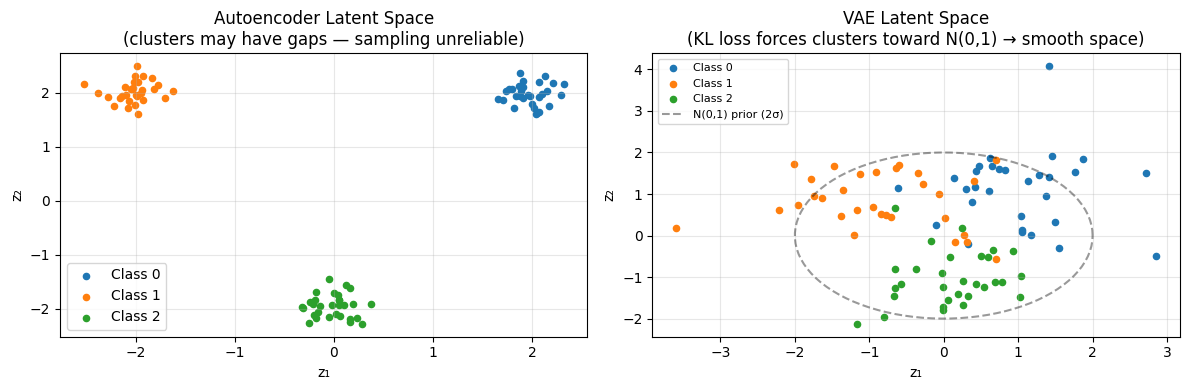

VAE key insight: KL term forces the latent distribution toward N(0,1).
This means you can sample any z ~ N(0,1) and decode it into a valid image.
In an AE, random z might fall in a 'gap' between clusters → garbage output.


In [4]:
# Visualise AE vs VAE latent space conceptually
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# AE — discrete points in latent space
np.random.seed(42)
ae_clusters = [
    np.random.randn(30, 2) * 0.2 + [2, 2],
    np.random.randn(30, 2) * 0.2 + [-2, 2],
    np.random.randn(30, 2) * 0.2 + [0, -2],
]
for i, cluster in enumerate(ae_clusters):
    axes[0].scatter(cluster[:,0], cluster[:,1], label=f'Class {i}', s=20)
axes[0].set_title('Autoencoder Latent Space\n(clusters may have gaps — sampling unreliable)')
axes[0].set_xlabel('z₁')
axes[0].set_ylabel('z₂')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# VAE — smooth latent space from KL regularization
vae_clusters = [
    np.random.randn(30, 2) * 0.8 + [1, 1],
    np.random.randn(30, 2) * 0.8 + [-1, 1],
    np.random.randn(30, 2) * 0.8 + [0, -1],
]
for i, cluster in enumerate(vae_clusters):
    axes[1].scatter(cluster[:,0], cluster[:,1], label=f'Class {i}', s=20)

# Show the N(0,1) prior
theta = np.linspace(0, 2*np.pi, 100)
axes[1].plot(np.cos(theta)*2, np.sin(theta)*2, 'k--', alpha=0.4, label='N(0,1) prior (2σ)')
axes[1].set_title('VAE Latent Space\n(KL loss forces clusters toward N(0,1) → smooth space)')
axes[1].set_xlabel('z₁')
axes[1].set_ylabel('z₂')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("VAE key insight: KL term forces the latent distribution toward N(0,1).")
print("This means you can sample any z ~ N(0,1) and decode it into a valid image.")
print("In an AE, random z might fall in a 'gap' between clusters → garbage output.")

## Exam Quick-Reference Summary

| Model | Two parts | Training objective |
|---|---|---|
| AE | Encoder + Decoder | Reconstruct input |
| VAE | Encoder + Decoder | Reconstruct + KL divergence (smooth latent space) |
| GAN | Generator + Discriminator | G fools D; D distinguishes real vs fake |
| Diffusion | U-Net denoiser | Learn to remove small amounts of noise at each step |

**GAN objectives (1 sentence each):**
- **Generator:** minimise the probability that the discriminator correctly identifies its output as fake
- **Discriminator:** maximise accuracy at classifying real images as real and fake images as fake

**Diffusion core idea (2 sentences):**
> Images are gradually corrupted with noise over T steps (forward process). A neural network learns to reverse this process step by step, enabling generation by starting from pure noise and iteratively denoising.

**Why small steps?** Each step is a simpler regression problem; one big step from noise to image is too hard to learn.

---
## 5. Practical Code — GAN & Diffusion with Neural Networks

The sections below give clean, runnable PyTorch implementations so you can **see** exactly how each architecture trains.

### What you will build
| # | Model | Task | Dataset |
|---|---|---|---|
| 5.1 | Vanilla GAN | Generate hand-written digits | MNIST (flat) |
| 5.2 | DCGAN | Better GAN with Conv layers | MNIST (2-D) |
| 5.3 | Simple Diffusion | Forward noising + tiny denoiser | Toy 2-D Gaussians |

> **Tip:** These run on CPU in a reasonable time for demo purposes. Increase `N_EPOCHS` for better quality.


In [ ]:
# ============================================================
# 5.1  Vanilla GAN — Generator vs Discriminator on MNIST
# Architecture: fully-connected (MLP) networks
# Reference:    Goodfellow et al. 2014  (the original GAN paper)
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

# ── Hyper-parameters ──────────────────────────────────────
LATENT_DIM  = 64       # size of the noise vector fed to G
IMG_DIM     = 28 * 28  # MNIST image flattened
HIDDEN_DIM  = 256
N_EPOCHS    = 10       # increase for better images; 30+ recommended
BATCH_SIZE  = 128
LR          = 2e-4
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Data ──────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])   # scale to [-1, 1]
])
train_data = datasets.MNIST(root="./data", train=True,
                            download=True, transform=transform)
loader     = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)

# ── Generator G: noise z  →  fake image ──────────────────
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, HIDDEN_DIM),
            nn.LeakyReLU(0.2),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM * 2),
            nn.LeakyReLU(0.2),
            nn.Linear(HIDDEN_DIM * 2, IMG_DIM),
            nn.Tanh()            # outputs in [-1, 1] — same range as data
        )
    def forward(self, z):
        return self.net(z)

# ── Discriminator D: image  →  P(real) ────────────────────
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(IMG_DIM, HIDDEN_DIM * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(HIDDEN_DIM * 2, HIDDEN_DIM),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(HIDDEN_DIM, 1),
            nn.Sigmoid()         # probability: 1=real, 0=fake
        )
    def forward(self, x):
        return self.net(x)

G = Generator().to(DEVICE)
D = Discriminator().to(DEVICE)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))

# Fixed noise to watch progress over epochs
fixed_noise = torch.randn(16, LATENT_DIM, device=DEVICE)

g_losses, d_losses = [], []

# ── Training loop ─────────────────────────────────────────
for epoch in range(N_EPOCHS):
    g_ep, d_ep = 0.0, 0.0

    for real_imgs, _ in loader:
        real_imgs = real_imgs.view(-1, IMG_DIM).to(DEVICE)
        bs = real_imgs.size(0)

        real_labels = torch.ones(bs, 1, device=DEVICE)
        fake_labels = torch.zeros(bs, 1, device=DEVICE)

        # ---- Train Discriminator ----
        # Loss on real: D should output 1 → log(D(x))
        loss_real = criterion(D(real_imgs), real_labels)

        z         = torch.randn(bs, LATENT_DIM, device=DEVICE)
        fake_imgs = G(z).detach()   # detach: no G gradients here
        # Loss on fake: D should output 0 → log(1-D(G(z)))
        loss_fake = criterion(D(fake_imgs), fake_labels)

        loss_D = (loss_real + loss_fake) / 2
        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # ---- Train Generator ----
        # G wants D to call its output "real" → label=1
        z         = torch.randn(bs, LATENT_DIM, device=DEVICE)
        fake_imgs = G(z)
        loss_G    = criterion(D(fake_imgs), real_labels)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        g_ep += loss_G.item()
        d_ep += loss_D.item()

    g_losses.append(g_ep / len(loader))
    d_losses.append(d_ep / len(loader))
    print(f"Epoch [{epoch+1:2d}/{N_EPOCHS}]  Loss_D: {d_losses[-1]:.4f}  Loss_G: {g_losses[-1]:.4f}")

# ── Visualise generated samples ───────────────────────────
G.eval()
with torch.no_grad():
    fake = G(fixed_noise).cpu().view(-1, 28, 28)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(fake[i].numpy() * 0.5 + 0.5, cmap="gray")
    ax.axis("off")
plt.suptitle(f"Vanilla GAN — generated digits after {N_EPOCHS} epochs", fontsize=13)
plt.tight_layout()
plt.show()

# ── Loss curves ───────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.plot(g_losses, label="Generator loss")
plt.plot(d_losses, label="Discriminator loss")
plt.xlabel("Epoch"); plt.ylabel("BCE Loss")
plt.title("GAN training dynamics")
plt.legend(); plt.tight_layout(); plt.show()
print("\nKey insight: if D loss -> 0, G is failing (D wins the game).")
print("Healthy GAN: both losses hover around 0.5-0.7 (neither player dominates).")



---
### 5.2  DCGAN — Deep Convolutional GAN

DCGAN (Radford et al., 2015) replaces the flat MLP with **Conv / ConvTranspose** layers.

**Key design rules (exam-worthy):**
- Replace pooling with **strided convolutions** (D) and **transposed convolutions** (G)
- Use **BatchNorm** in both G and D (except output layers)
- Use **ReLU** in G, **LeakyReLU** in D
- Output layer of G: `Tanh`; output layer of D: `Sigmoid`


In [ ]:
# ============================================================
# 5.2  DCGAN — Convolutional GAN on MNIST
# Reference: Radford et al. 2015  "Unsupervised Representation
#            Learning with Deep Convolutional Generative
#            Adversarial Networks"
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)

LATENT_DIM = 100
N_EPOCHS   = 10
BATCH_SIZE = 128
LR         = 2e-4
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# MNIST padded to 32x32 so ConvTranspose halving works cleanly
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
loader = DataLoader(
    datasets.MNIST("./data", train=True, download=True, transform=transform),
    batch_size=BATCH_SIZE, shuffle=True
)

# ── DCGAN Generator: z (100,) → image (1,32,32) ─────────
class DCGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # Project & reshape: z → 256 feature maps of 2x2
            nn.ConvTranspose2d(LATENT_DIM, 256, kernel_size=2, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),      # -> 256x2x2
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),      # -> 128x4x4
            nn.ConvTranspose2d(128, 64,  kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),  nn.ReLU(True),      # -> 64x8x8
            nn.ConvTranspose2d(64,  32,  kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),  nn.ReLU(True),      # -> 32x16x16
            nn.ConvTranspose2d(32,  1,   kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()                                # -> 1x32x32
        )
    def forward(self, z):
        # z shape: (B, LATENT_DIM) → need (B, LATENT_DIM, 1, 1)
        return self.net(z.view(-1, LATENT_DIM, 1, 1))

# ── DCGAN Discriminator: image → scalar ─────────────────
class DCDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32,  kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, True),                        # -> 32x16x16
            nn.Conv2d(32, 64,  kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),  nn.LeakyReLU(0.2, True),  # -> 64x8x8
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),  # -> 128x4x4
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2, True),  # -> 256x2x2
            nn.Conv2d(256, 1,   kernel_size=2, stride=1, padding=0, bias=False),
            nn.Sigmoid()                                    # -> 1x1x1
        )
    def forward(self, x):
        return self.net(x).view(-1, 1)

G_dc = DCGenerator().to(DEVICE)
D_dc = DCDiscriminator().to(DEVICE)

def weights_init(m):
    """DCGAN paper recommends N(0, 0.02) for conv weights."""
    if isinstance(m, (nn.ConvTranspose2d, nn.Conv2d)):
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G_dc.apply(weights_init)
D_dc.apply(weights_init)

criterion = nn.BCELoss()
opt_G = optim.Adam(G_dc.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = optim.Adam(D_dc.parameters(), lr=LR, betas=(0.5, 0.999))

fixed_noise = torch.randn(16, LATENT_DIM, device=DEVICE)
g_losses, d_losses = [], []

for epoch in range(N_EPOCHS):
    g_ep = d_ep = 0.0
    for real_imgs, _ in loader:
        real_imgs = real_imgs.to(DEVICE)
        bs = real_imgs.size(0)
        ones  = torch.ones(bs, 1, device=DEVICE)
        zeros = torch.zeros(bs, 1, device=DEVICE)

        # ---- Discriminator step ----
        z         = torch.randn(bs, LATENT_DIM, device=DEVICE)
        fake_imgs = G_dc(z).detach()
        loss_D = (criterion(D_dc(real_imgs), ones) +
                  criterion(D_dc(fake_imgs), zeros)) / 2
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # ---- Generator step ----
        z         = torch.randn(bs, LATENT_DIM, device=DEVICE)
        fake_imgs = G_dc(z)
        loss_G    = criterion(D_dc(fake_imgs), ones)
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

        g_ep += loss_G.item(); d_ep += loss_D.item()

    g_losses.append(g_ep / len(loader))
    d_losses.append(d_ep / len(loader))
    print(f"Epoch [{epoch+1:2d}/{N_EPOCHS}]  Loss_D: {d_losses[-1]:.4f}  Loss_G: {g_losses[-1]:.4f}")

# ── Show results ─────────────────────────────────────────
G_dc.eval()
with torch.no_grad():
    fake = G_dc(fixed_noise).cpu().squeeze(1)   # (16, 32, 32)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(fake[i].numpy() * 0.5 + 0.5, cmap="gray")
    ax.axis("off")
plt.suptitle(f"DCGAN — generated digits after {N_EPOCHS} epochs", fontsize=13)
plt.tight_layout(); plt.show()

print("DCGAN vs Vanilla GAN: conv layers preserve spatial structure")
print(" -> sharper, more coherent images than the flat MLP GAN.")



---
### 5.3  Simple Diffusion Model — Forward Noising + Neural Denoiser

A diffusion model has **two processes**:

| Process | Direction | What happens |
|---|---|---|
| **Forward (q)** | data → noise | Gradually add Gaussian noise over T steps |
| **Reverse (p_θ)** | noise → data | Neural network learns to **remove** the noise |

**Why many small steps and not one big jump?**  
Each small step has a tractable Gaussian posterior that the network can learn. One big jump gives a complex, intractable distribution. Small steps → stable training.

We demo on **toy 2-D data** (a mixture of Gaussians) so you can visualise both processes without a GPU.


In [ ]:
# ============================================================
# 5.3  Toy Diffusion Model
#      Forward process: x_t = sqrt(alpha_bar_t)*x_0 + sqrt(1-alpha_bar_t)*eps
#      Reverse process: small NN predicts the noise eps at each step
#      Data:  2-D mixture of 5 Gaussians (runs fully on CPU)
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 1. Toy dataset: ring of 5 Gaussians ──────────────────
def make_data(n=5000):
    centres = torch.tensor(
        [(np.cos(2*np.pi*k/5), np.sin(2*np.pi*k/5)) for k in range(5)],
        dtype=torch.float32
    )
    idx  = torch.randint(5, (n,))
    data = centres[idx] + 0.15 * torch.randn(n, 2)
    return data

x_data = make_data().to(DEVICE)   # (5000, 2)

# ── 2. Noise schedule (linear beta schedule) ─────────────
T          = 300               # total diffusion steps
beta_start = 1e-4
beta_end   = 0.02
betas      = torch.linspace(beta_start, beta_end, T, device=DEVICE)
alphas     = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)  # alpha_bar_t

def q_sample(x0, t):
    """Forward diffusion: directly compute x_t from x_0 in one closed-form step."""
    ab  = alpha_bars[t].view(-1, 1)          # (B, 1)
    eps = torch.randn_like(x0)
    x_t = ab.sqrt() * x0 + (1 - ab).sqrt() * eps
    return x_t, eps

# ── 3. Sinusoidal time embedding ──────────────────────────
class SinusoidalTimeEmb(nn.Module):
    """Encode scalar timestep t as a fixed sinusoidal embedding (like transformer PE)."""
    def __init__(self, dim=16):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(
            -np.log(10000) * torch.arange(half, device=t.device) / half
        )
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)  # (B, half)
        return torch.cat([args.sin(), args.cos()], dim=1)   # (B, dim)

# ── 4. Denoising MLP: predicts added noise eps ────────────
#    Input:  x_t (2-D) concatenated with time embedding (16-D) = 18-D
#    Output: predicted noise eps (2-D)
class DenoiseMLP(nn.Module):
    def __init__(self, data_dim=2, time_emb_dim=16, hidden=128):
        super().__init__()
        self.time_emb = SinusoidalTimeEmb(time_emb_dim)
        self.net = nn.Sequential(
            nn.Linear(data_dim + time_emb_dim, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, data_dim),  # predict eps
        )
    def forward(self, x_t, t):
        te = self.time_emb(t)            # (B, time_emb_dim)
        h  = torch.cat([x_t, te], dim=1)
        return self.net(h)

model     = DenoiseMLP().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=3e-4)
print(f"Denoiser params: {sum(p.numel() for p in model.parameters()):,}")

# ── 5. Training: minimise ||eps_pred - eps_true||^2 ───────
N_EPOCHS = 500
BATCH    = 512
losses   = []

for epoch in range(N_EPOCHS):
    idx  = torch.randint(len(x_data), (BATCH,))
    x0   = x_data[idx]                              # (B, 2)
    t    = torch.randint(0, T, (BATCH,), device=DEVICE)
    x_t, eps_true = q_sample(x0, t)

    eps_pred = model(x_t, t)
    loss = nn.functional.mse_loss(eps_pred, eps_true)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:4d}/{N_EPOCHS}  MSE loss: {loss.item():.5f}")

# ── 6. Reverse (sampling): start from pure noise → denoise ─
@torch.no_grad()
def p_sample_loop(n_samples=500):
    """DDPM reverse process: iteratively subtract predicted noise."""
    model.eval()
    x = torch.randn(n_samples, 2, device=DEVICE)   # start from N(0, I)

    for t_val in reversed(range(T)):
        t_tensor    = torch.full((n_samples,), t_val, dtype=torch.long, device=DEVICE)
        alpha_t     = alphas[t_val]
        alpha_bar_t = alpha_bars[t_val]
        beta_t      = betas[t_val]

        eps_pred = model(x, t_tensor)

        # DDPM posterior mean (eq. 11 in Ho et al. 2020)
        x = (1 / alpha_t.sqrt()) * (
            x - (beta_t / (1 - alpha_bar_t).sqrt()) * eps_pred
        )
        # Add noise at all steps except the last
        if t_val > 0:
            x = x + beta_t.sqrt() * torch.randn_like(x)

    return x.cpu().numpy()

samples = p_sample_loop(1000)

# ── 7. Visualise ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Ground-truth data
ax = axes[0]
gt = x_data.cpu().numpy()
ax.scatter(gt[:, 0], gt[:, 1], s=3, alpha=0.4, c="steelblue")
ax.set_title("Ground-truth data\n(5-cluster ring)"); ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)

# Forward diffusion snapshots at different timesteps
ax = axes[1]
x0_sample = x_data[:300].cpu()
for ts, col, lbl in [(0, "#3498db", "t=0 (data)"),
                     (50,  "#2ecc71", "t=50"),
                     (150, "#f39c12", "t=150"),
                     (299, "#e74c3c", "t=299 (noise)")]:
    t_tensor = torch.full((300,), ts, dtype=torch.long)
    xt, _    = q_sample(x0_sample, t_tensor)
    xt_np    = xt.numpy()
    ax.scatter(xt_np[:, 0], xt_np[:, 1], s=5, alpha=0.5, c=col, label=lbl)
ax.legend(fontsize=7); ax.set_title("Forward diffusion\n(data → pure noise)")
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)

# Generated samples (reverse: noise → data)
ax = axes[2]
ax.scatter(samples[:, 0], samples[:, 1], s=3, alpha=0.5, c="coral")
ax.set_title(f"Generated samples\n(reverse diffusion, {N_EPOCHS} epochs)")
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)

plt.suptitle("Toy Diffusion Model (2-D Gaussians)", fontsize=13)
plt.tight_layout(); plt.show()

# Loss curve
plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.xlabel("Training step"); plt.ylabel("MSE loss")
plt.title("Diffusion denoiser training loss"); plt.tight_layout(); plt.show()

print("\nCore equations:")
print("  Forward:  x_t = sqrt(ab_t)*x_0 + sqrt(1-ab_t)*eps   (closed form)")
print("  Network:  eps_theta(x_t, t)  learns to predict eps")
print("  Reverse:  x_{t-1} = (1/sqrt(a_t)) * (x_t - b_t/sqrt(1-ab_t)*eps_theta) + noise")



---
### 5.4  GAN vs Diffusion — Quick Comparison

| Property | GAN | Diffusion |
|---|---|---|
| Training objective | Minimax game (adversarial) | MSE on predicted noise (regression) |
| Training stability | Notoriously unstable (mode collapse) | Stable, no adversarial game |
| Inference speed | Fast — one forward pass through G | Slow — T denoising steps |
| Sample diversity | Can suffer mode collapse | Generally better coverage |
| State of the art | StyleGAN3, BigGAN | DALL·E 3, Stable Diffusion, Sora |

**Exam shortcut:**  
- GANs = adversarial (two competing networks — G tries to fool D).  
- Diffusion = iterative denoising (one network, T small steps of noise removal).  
- VAEs = encode to latent mean/variance, sample with reparameterisation trick.
